In [1]:
# Copyright (C) 2024 Richard Stiskalek
# This program is free software; you can redistribute it and/or modify it
# under the terms of the GNU General Public License as published by the
# Free Software Foundation; either version 3 of the License, or (at your
# option) any later version.
#
# This program is distributed in the hope that it will be useful, but
# WITHOUT ANY WARRANTY; without even the implied warranty of
# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the GNU General
# Public License for more details.
#
# You should have received a copy of the GNU General Public License along
# with this program; if not, write to the Free Software Foundation, Inc.,
# 51 Franklin Street, Fifth Floor, Boston, MA  02110-1301, USA.
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

import csiborgtools

%load_ext autoreload
%autoreload 2
%matplotlib inline

paths = csiborgtools.read.Paths(**csiborgtools.paths_glamdring)
fdir = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity"


ra, dec = csiborgtools.galactic_to_radec(117, 4)
print("Void axis: ", csiborgtools.radec_to_cartesian(np.array([1., ra, dec]).reshape(-1, 3)))

Void axis:  [[ 0.4035093  -0.01363162  0.91487399]]


In [2]:
def rand_points_in_sphere(rmax, N):
    r = rmax * np.random.rand(N)**(1./3.)
    theta = np.arccos(2*np.random.rand(N)-1)
    phi = 2*np.pi*np.random.rand(N)
    return r[:, None] * np.vstack([
        np.sin(theta) * np.cos(phi),
        np.sin(theta) * np.sin(phi),
        np.cos(theta)]).T

In [25]:
r_grid = np.arange(0, 251)
phi_grid = np.arange(0, 181)


size, rLG, vx = csiborgtools.flow.load_void_size_variation("exp", "vx",)
size, rLG, vy = csiborgtools.flow.load_void_size_variation("exp", "vy")
size, rLG, vrad = csiborgtools.flow.load_void_size_variation("exp", "vrad")

# rLG, vx = csiborgtools.flow.load_void_fiducial("exp", "vx")
# rLG, vy = csiborgtools.flow.load_void_fiducial("exp", "vy")
# rLG, vrad = csiborgtools.flow.load_void_fiducial("exp", "vrad")


2024-12-03 14:35:57   loading pre-processed data from `/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation_new/processed_exp_vx.hdf5`.
2024-12-03 14:38:47   loading pre-processed data from `/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation_new/processed_exp_vy.hdf5`.
2024-12-03 14:41:02   loading pre-processed data from `/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation_new/processed_exp_vrad.hdf5`.


In [ ]:
rmax = 150
r = np.linspace(0, rmax, 100)
ngrid = 64

kgrid = 10
kobs = 30

print(f"Chosen a void size at {(100 * size[kgrid]):.2f}%")
print(f"Chosen an observer at {rLG[kobs]:.2f} Mpc")

# Unit vector in the direction of the Watkins bulk flow
unit_vvoid =  np.asarray([-0.4035093, 0.01363162, -0.91487399])

bulk_flow = csiborgtools.flow.void_bulk_flow(
    r, vx[kgrid, kobs], vy[kgrid, kobs], ngrid, r_grid, phi_grid, in_icrs=True)
# monopole = csiborgtools.flow.void_monopole(r, vrad[kgrid, kobs], ngrid, r_grid, phi_grid)

Chosen an observer at 50.00 Mpc


100%|██████████| 100/100 [00:00<00:00, 1276.36it/s]


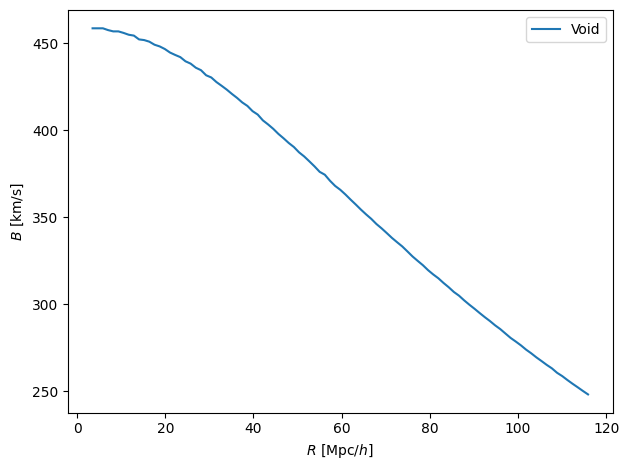

In [27]:
fig, ax = plt.subplots()

ax.plot(r * csiborgtools.flow.select_void_h("exp"),
         np.linalg.norm(bulk_flow + 0 * unit_vvoid[None, :], axis=1),
         label="Void")


x_watkins = np.asarray([99.47368421052632, 125.26315789473685, 150, 175.26315789473682, 200, 225.26315789473682, 249.4736842105263])
y_watkins = np.asarray([304.76190476190476, 347.6190476190476, 388.0952380952381, 407.1428571428571, 421.42857142857144, 426.19047619047615, 426.19047619047615])
m = x_watkins < 250 * csiborgtools.flow.select_void_h("exp")
# plt.plot(x_watkins[m], y_watkins[m], label="Watkins")


plt.xlabel(r"$R ~ [\mathrm{Mpc} / h]$")
plt.ylabel(r"$B ~ [\mathrm{km} / \mathrm{s}]$")
plt.legend()

plt.tight_layout()
# plt.savefig("../../plots/bf_example.png", dpi=300)
plt.show()